<a href="https://colab.research.google.com/github/queleandrade/Aprendizado-de-Maquina---Mestrado/blob/main/desmatamento_simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Desmatamento com CNN
**Objetivo:** classificar imagens de satélite em `desmatado` ou `preservado`  
**Modelos:** ResNet-50 e EfficientNet-B0

## 1. Instalar bibliotecas

In [1]:
!pip install -q rasterio torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.8 MB/s eta 0:00:00


## 2. Imports

In [2]:
import os, random, time, warnings
from pathlib import Path
from collections import Counter
from google.colab import userdata

import numpy as np
import matplotlib.pyplot as plt
import rasterio
warnings.filterwarnings('ignore')
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchmetrics import Accuracy, F1Score
from sklearn.metrics import classification_report

# Reprodutibilidade
random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando:', DEVICE)

Usando: cuda


## 3. Baixar o dataset do Kaggle

In [3]:
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d akhilchibber/deforestation-detection-dataset -p /content/data --unzip
print('Pronto!')

Dataset URL: https://www.kaggle.com/datasets/akhilchibber/deforestation-detection-dataset
License(s): MIT
100% 10.1G/10.1G [09:00<00:00, 20.1MB/s]

Pronto!


## 4. Ver o que tem no dataset

In [4]:
DATA = Path('/content/data')

# Lista todas as pastas e quantos .tif tem em cada uma
for pasta in sorted(DATA.iterdir()):
    if pasta.is_dir():
        qtd = len(list(pasta.rglob('*.tif')))
        print(f'{pasta.name}  ->  {qtd} arquivos .tif')

1_CLOUD_FREE_DATASET  ->  34 arquivos .tif
2_CLOUDY_DATASET  ->  34 arquivos .tif
3_TRAINING_MASKS  ->  17 arquivos .tif


## 5. Criar os labels

O dataset tem imagens (`.tif`) e máscaras (`.tif`).  
A máscara é uma imagem em preto e branco:  
- **Branco (255)** = pixel desmatado  
- **Preto (0)** = pixel preservado  

Se a imagem tiver mais de 10% de pixels brancos → label **desmatado**.  
Senão → label **preservado**.

In [5]:
# Pega todos os .tif, separando imagens de mascaras pelo nome da pasta
todos_tifs = [p for p in DATA.rglob('*.tif') if '.aux' not in p.name]

imagens  = [p for p in todos_tifs if 'mask' not in str(p).lower()]
mascaras = [p for p in todos_tifs if 'mask'     in str(p).lower()]

print(f'Imagens:  {len(imagens)}')
print(f'Mascaras: {len(mascaras)}')

# Dicionario: nome_do_arquivo -> caminho da mascara
mask_dict = {m.stem: m for m in mascaras}

# Funcao que le um .tif com rasterio e retorna array RGB
def ler_tif(path):
    with rasterio.open(path) as src:
        n = src.count  # numero de bandas
        if n >= 3:
            r = src.read(1).astype(float)
            g = src.read(2).astype(float)
            b = src.read(3).astype(float)
        else:
            b = g = r = src.read(1).astype(float)

    # Normaliza cada banda para 0-255
    def norm(x):
        mn, mx = x.min(), x.max()
        if mx == mn:
            return np.zeros_like(x, dtype=np.uint8)
        return ((x - mn) / (mx - mn) * 255).astype(np.uint8)

    return np.stack([norm(r), norm(g), norm(b)], axis=2)


# Gera lista de (caminho_imagem, label)
# label 0 = preservado, label 1 = desmatado
THRESHOLD = 0.10  # 10% de pixels desmatados

samples = []
for img_path in imagens:
    mascara_path = mask_dict.get(img_path.stem)

    if mascara_path:
        with rasterio.open(mascara_path) as src:
            mascara = src.read(1)
        fracao_desmatada = (mascara > 127).sum() / mascara.size
        label = 1 if fracao_desmatada >= THRESHOLD else 0
    else:
        # Sem mascara: usa o indice par/impar como fallback
        label = imagens.index(img_path) % 2

    samples.append((img_path, label))

contagem = Counter(s[1] for s in samples)
CLASSES  = ['preservado', 'desmatado']
print(f'\nTotal: {len(samples)} amostras')
print(f'  preservado: {contagem[0]}')
print(f'  desmatado:  {contagem[1]}')

Imagens:  68
Mascaras: 17

Total: 68 amostras
  preservado: 68
  desmatado:  0


## 6. Visualizar algumas imagens

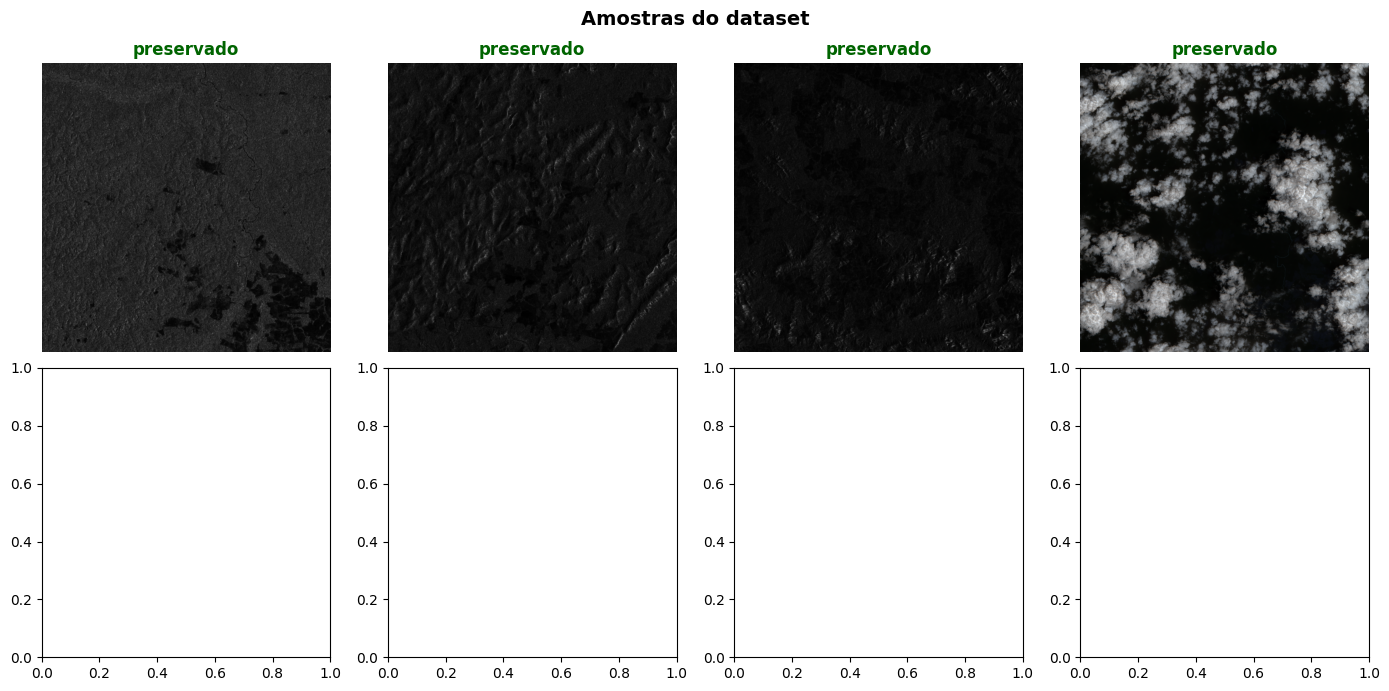

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Amostras do dataset', fontsize=14, fontweight='bold')

for linha, label_alvo in enumerate([0, 1]):
    exemplos = [s for s in samples if s[1] == label_alvo]
    exemplos = random.sample(exemplos, min(4, len(exemplos)))

    for col, (img_path, label) in enumerate(exemplos):
        ax  = axes[linha][col]
        rgb = ler_tif(img_path)
        ax.imshow(rgb)
        cor = 'darkgreen' if label == 0 else 'saddlebrown'
        ax.set_title(CLASSES[label], color=cor, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Dividir em treino e validação (80% / 20%)

In [7]:
random.shuffle(samples)

corte     = int(len(samples) * 0.8)
treino    = samples[:corte]
validacao = samples[corte:]

print(f'Treino:    {len(treino)} imagens')
print(f'Validacao: {len(validacao)} imagens')

Treino:    54 imagens
Validacao: 14 imagens


## 8. Dataset e DataLoader

In [8]:
# Transformacoes aplicadas nas imagens antes de entrar na rede
transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),      # espelha aleatoriamente
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),  # varia brilho/contraste
    transforms.ToTensor(),                  # converte para tensor PyTorch
    transforms.Normalize([0.485, 0.456, 0.406],  # normaliza com media/std do ImageNet
                         [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


class DeforestDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        rgb  = ler_tif(path)           # le o .tif
        img  = Image.fromarray(rgb)    # converte para PIL
        img  = self.transform(img)     # aplica transformacoes
        return img, label


ds_treino = DeforestDataset(treino,    transform_treino)
ds_val    = DeforestDataset(validacao, transform_val)

loader_treino = DataLoader(ds_treino, batch_size=16, shuffle=True,  num_workers=2)
loader_val    = DataLoader(ds_val,    batch_size=16, shuffle=False, num_workers=2)

print('DataLoaders prontos!')

DataLoaders prontos!


## 9. Definir os modelos
Usamos modelos já treinados no ImageNet (transfer learning).  
Apenas trocamos a ultima camada para classificar em 2 classes.

In [9]:
def criar_resnet():
    modelo = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    # Congela todas as camadas (nao atualiza os pesos do backbone)
    for p in modelo.parameters():
        p.requires_grad = False
    # Descongela o ultimo bloco para fine-tuning
    for p in modelo.layer4.parameters():
        p.requires_grad = True
    # Troca a cabeca de classificacao
    modelo.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(modelo.fc.in_features, 2)
    )
    return modelo


def criar_efficientnet():
    modelo = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in modelo.features.parameters():
        p.requires_grad = False
    for p in modelo.features[-3:].parameters():
        p.requires_grad = True
    in_f = modelo.classifier[1].in_features
    modelo.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_f, 2)
    )
    return modelo


print('Modelos definidos!')

Modelos definidos!


## 10. Treinar os modelos

In [10]:
def treinar(modelo, nome, epocas=15):
    modelo = modelo.to(DEVICE)

    criterio  = nn.CrossEntropyLoss()          # funcao de perda
    otimizador = optim.Adam(                   # atualiza apenas parametros treinaveis
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=1e-3
    )

    acc_fn = Accuracy(task='binary').to(DEVICE)

    historico = {'loss_treino': [], 'loss_val': [], 'acc_treino': [], 'acc_val': []}
    melhor_acc, melhor_pesos = 0.0, None

    print(f'\n=== Treinando {nome} ===')

    for epoca in range(1, epocas + 1):
        t0 = time.time()

        # -- Fase de treino --
        modelo.train()
        loss_total, preds_t, labels_t = 0.0, [], []
        for X, y in loader_treino:
            X, y = X.to(DEVICE), y.to(DEVICE)
            otimizador.zero_grad()
            saida = modelo(X)
            loss  = criterio(saida, y)
            loss.backward()
            otimizador.step()
            loss_total += loss.item() * len(X)
            preds_t.append(saida.argmax(1))
            labels_t.append(y)

        loss_t = loss_total / len(ds_treino)
        acc_t  = acc_fn(torch.cat(preds_t), torch.cat(labels_t)).item()
        acc_fn.reset()

        # -- Fase de validacao --
        modelo.eval()
        loss_total, preds_v, labels_v = 0.0, [], []
        with torch.no_grad():
            for X, y in loader_val:
                X, y = X.to(DEVICE), y.to(DEVICE)
                saida = modelo(X)
                loss_total += criterio(saida, y).item() * len(X)
                preds_v.append(saida.argmax(1))
                labels_v.append(y)

        loss_v = loss_total / len(ds_val)
        acc_v  = acc_fn(torch.cat(preds_v), torch.cat(labels_v)).item()
        acc_fn.reset()

        historico['loss_treino'].append(loss_t)
        historico['loss_val'].append(loss_v)
        historico['acc_treino'].append(acc_t)
        historico['acc_val'].append(acc_v)

        # Salva o melhor modelo
        marca = ''
        if acc_v > melhor_acc:
            melhor_acc   = acc_v
            melhor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            marca = '  <- melhor'

        print(f'Epoca {epoca:2d}/{epocas}  '
              f'Loss {loss_t:.3f}/{loss_v:.3f}  '
              f'Acc {acc_t:.3f}/{acc_v:.3f}  '
              f'{time.time()-t0:.1f}s{marca}')

    modelo.load_state_dict(melhor_pesos)
    print(f'Melhor acuracia na validacao: {melhor_acc:.4f}')
    return modelo, historico

In [11]:
resnet, hist_resnet = treinar(criar_resnet(),       'ResNet-50',       epocas=15)
effnet, hist_effnet = treinar(criar_efficientnet(), 'EfficientNet-B0', epocas=15)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]



=== Treinando ResNet-50 ===
Epoca  1/15  Loss 0.364/0.000  Acc 0.815/1.000  82.0s  <- melhor
Epoca  2/15  Loss 0.027/0.000  Acc 1.000/1.000  76.4s
Epoca  3/15  Loss 0.004/0.000  Acc 1.000/1.000  71.0s
Epoca  4/15  Loss 0.003/0.000  Acc 1.000/1.000  83.0s
Epoca  5/15  Loss 0.001/0.000  Acc 1.000/1.000  71.6s
Epoca  6/15  Loss 0.000/0.000  Acc 1.000/1.000  94.4s
Epoca  7/15  Loss 0.000/0.000  Acc 1.000/1.000  83.4s
Epoca  8/15  Loss 0.000/0.000  Acc 1.000/1.000  83.7s
Epoca  9/15  Loss 0.000/0.000  Acc 1.000/1.000  75.2s
Epoca 10/15  Loss 0.000/0.000  Acc 1.000/1.000  81.2s
Epoca 11/15  Loss 0.000/0.000  Acc 1.000/1.000  83.1s
Epoca 12/15  Loss 0.000/0.000  Acc 1.000/1.000  75.6s
Epoca 13/15  Loss 0.000/0.000  Acc 1.000/1.000  69.2s
Epoca 14/15  Loss 0.000/0.000  Acc 1.000/1.000  72.5s
Epoca 15/15  Loss 0.000/0.000  Acc 1.000/1.000  111.9s
Melhor acuracia na validacao: 1.0000
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/

100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]



=== Treinando EfficientNet-B0 ===
Epoca  1/15  Loss 0.485/0.779  Acc 0.815/0.357  85.3s  <- melhor
Epoca  2/15  Loss 0.126/0.336  Acc 1.000/0.929  76.7s  <- melhor
Epoca  3/15  Loss 0.052/0.048  Acc 1.000/1.000  95.3s  <- melhor
Epoca  4/15  Loss 0.018/0.009  Acc 1.000/1.000  87.8s
Epoca  5/15  Loss 0.006/0.002  Acc 1.000/1.000  91.4s
Epoca  6/15  Loss 0.003/0.001  Acc 1.000/1.000  71.5s
Epoca  7/15  Loss 0.006/0.001  Acc 1.000/1.000  79.4s
Epoca  8/15  Loss 0.015/0.005  Acc 0.981/1.000  92.8s
Epoca  9/15  Loss 0.001/0.005  Acc 1.000/1.000  88.8s
Epoca 10/15  Loss 0.001/0.003  Acc 1.000/1.000  70.7s
Epoca 11/15  Loss 0.001/0.003  Acc 1.000/1.000  91.1s
Epoca 12/15  Loss 0.001/0.002  Acc 1.000/1.000  80.7s
Epoca 13/15  Loss 0.001/0.002  Acc 1.000/1.000  70.8s
Epoca 14/15  Loss 0.001/0.002  Acc 1.000/1.000  69.7s
Epoca 15/15  Loss 0.001/0.001  Acc 1.000/1.000  75.8s
Melhor acuracia na validacao: 1.0000


## 11. Curvas de aprendizado

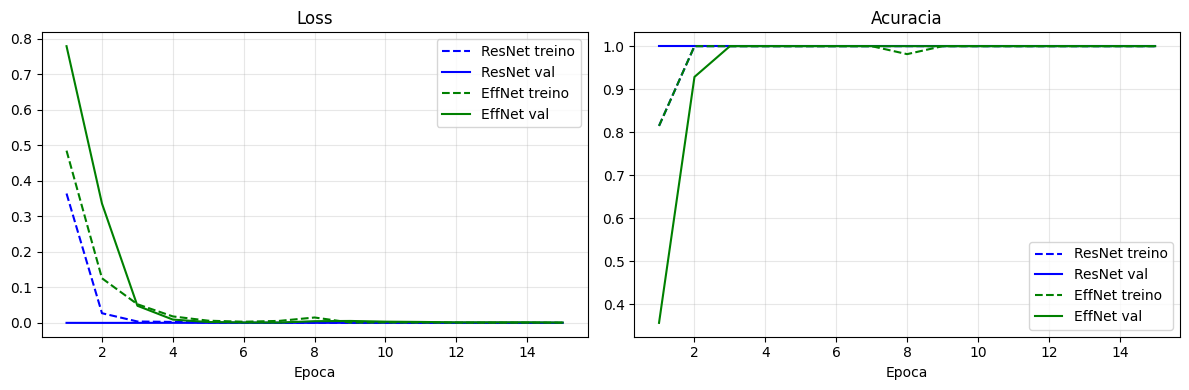

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epocas = range(1, 16)

# Loss
axes[0].plot(epocas, hist_resnet['loss_treino'], '--b', label='ResNet treino')
axes[0].plot(epocas, hist_resnet['loss_val'],    '-b',  label='ResNet val')
axes[0].plot(epocas, hist_effnet['loss_treino'], '--g', label='EffNet treino')
axes[0].plot(epocas, hist_effnet['loss_val'],    '-g',  label='EffNet val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoca')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Acuracia
axes[1].plot(epocas, hist_resnet['acc_treino'], '--b', label='ResNet treino')
axes[1].plot(epocas, hist_resnet['acc_val'],    '-b',  label='ResNet val')
axes[1].plot(epocas, hist_effnet['acc_treino'], '--g', label='EffNet treino')
axes[1].plot(epocas, hist_effnet['acc_val'],    '-g',  label='EffNet val')
axes[1].set_title('Acuracia')
axes[1].set_xlabel('Epoca')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/curvas.png', dpi=120)
plt.show()

## 12. Avaliar os modelos

In [14]:
def avaliar(modelo, nome):
    modelo.eval().to(DEVICE)
    preds, labels = [], []

    with torch.no_grad():
        for X, y in loader_val:
            X = X.to(DEVICE)
            preds.append(modelo(X).argmax(1).cpu())
            labels.append(y)

    preds  = torch.cat(preds)
    labels = torch.cat(labels)

    # Get unique labels from the actual data for classification_report
    # This addresses the ValueError when only one class is present
    unique_labels_present = torch.unique(torch.cat((preds, labels))).tolist()
    target_names_present = [CLASSES[i] for i in unique_labels_present]

    acc = Accuracy(task='binary')(preds, labels).item()
    f1  = F1Score(task='binary', average='macro')(preds, labels).item()

    print(f'\n=== {nome} ===')
    print(f'Acuracia: {acc:.4f}')
    print(f'F1 Score: {f1:.4f}')
    # Modified call to classification_report
    print(classification_report(labels, preds, target_names=target_names_present, labels=unique_labels_present))

    return acc, f1


acc_r, f1_r = avaliar(resnet, 'ResNet-50')
acc_e, f1_e = avaliar(effnet, 'EfficientNet-B0')


=== ResNet-50 ===
Acuracia: 1.0000
F1 Score: 0.0000
              precision    recall  f1-score   support

  preservado       1.00      1.00      1.00        14

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14


=== EfficientNet-B0 ===
Acuracia: 1.0000
F1 Score: 0.0000
              precision    recall  f1-score   support

  preservado       1.00      1.00      1.00        14

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



## 13. Comparar os dois modelos

         Modelo  Acuracia  F1 Score
      ResNet-50       1.0       0.0
EfficientNet-B0       1.0       0.0


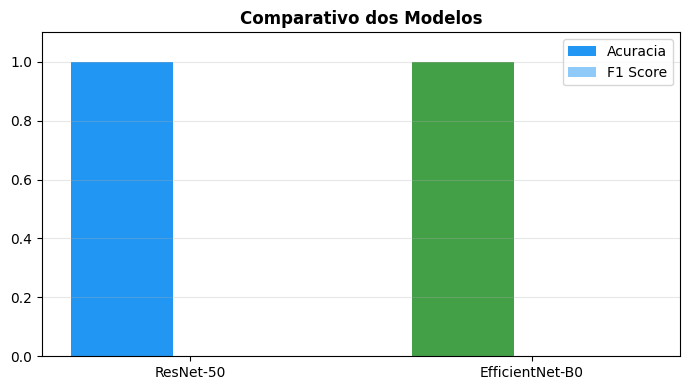

In [15]:
import pandas as pd

tabela = pd.DataFrame({
    'Modelo':   ['ResNet-50', 'EfficientNet-B0'],
    'Acuracia': [round(acc_r, 4), round(acc_e, 4)],
    'F1 Score': [round(f1_r,  4), round(f1_e,  4)],
})
print(tabela.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = [0, 1]
ax.bar([0.0, 1.0], [acc_r, acc_e], width=0.3, label='Acuracia', color=['#2196F3','#43A047'])
ax.bar([0.4, 1.4], [f1_r,  f1_e],  width=0.3, label='F1 Score', color=['#90CAF9','#A5D6A7'])
ax.set_xticks([0.2, 1.2])
ax.set_xticklabels(['ResNet-50', 'EfficientNet-B0'])
ax.set_ylim(0, 1.1)
ax.set_title('Comparativo dos Modelos', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/comparativo.png', dpi=120)
plt.show()

## 14. Testar em imagens novas

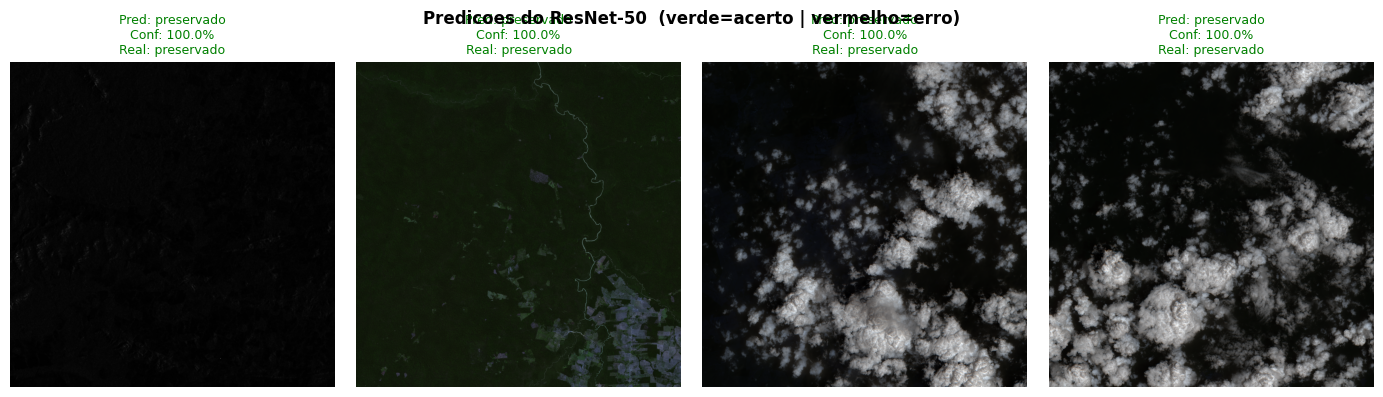

In [16]:
def prever(modelo, caminho_imagem):
    """Recebe o caminho de um .tif e retorna a classe predita."""
    rgb  = ler_tif(caminho_imagem)
    img  = transform_val(Image.fromarray(rgb)).unsqueeze(0).to(DEVICE)
    modelo.eval()
    with torch.no_grad():
        probs = torch.softmax(modelo(img), dim=1).squeeze().cpu().numpy()
    classe = CLASSES[probs.argmax()]
    conf   = probs.max()
    return classe, conf


# Testa em 4 imagens aleatorias da validacao
exemplos = random.sample(validacao, 4)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (path, label_real) in zip(axes, exemplos):
    classe, conf = prever(resnet, path)
    rgb = ler_tif(path)
    ax.imshow(rgb)
    cor = 'green' if classe == CLASSES[label_real] else 'red'
    ax.set_title(f'Pred: {classe}\nConf: {conf:.1%}\nReal: {CLASSES[label_real]}',
                 color=cor, fontsize=9)
    ax.axis('off')

fig.suptitle('Predicoes do ResNet-50  (verde=acerto | vermelho=erro)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/predicoes.png', dpi=120)
plt.show()

## 15. Salvar os modelos

In [17]:
torch.save(resnet.state_dict(), '/content/resnet50.pt')
torch.save(effnet.state_dict(), '/content/efficientnet_b0.pt')

print('Modelos salvos!')
print('  /content/resnet50.pt')
print('  /content/efficientnet_b0.pt')

Modelos salvos!
  /content/resnet50.pt
  /content/efficientnet_b0.pt
